In [8]:
import numpy as np 
import pandas as pd

df = pd.read_csv('ACC_minute.csv')
df.head()

,date,open,high,low,close,volume
0,2015-02-02 09:15:00,1554.90,1556.70,1544.80,1549.60,1441
1,2015-02-02 09:16:00,1550.70,1551.30,1546.50,1548.30,424
2,2015-02-02 09:17:00,1548.35,1549.00,1545.15,1547.55,831
3,2015-02-02 09:18:00,1547.55,1547.55,1543.00,1544.20,1297
4,2015-02-02 09:19:00,1544.25,1547.75,1544.25,1547.75,255


In [9]:
df.isna().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [10]:
x = df['high']
y = df['low']
corr = np.corrcoef(x.to_numpy().ravel(),y.to_numpy().ravel())
corr


array([[1.       , 0.9999901],
       [0.9999901, 1.       ]])

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

train = LinearRegression().fit(x_train.values.reshape(-1,1),y_train.values.reshape(-1,1))
y_pred = train.predict(x_test.values.reshape(-1,1))

r2_score(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

1.0808581995166135

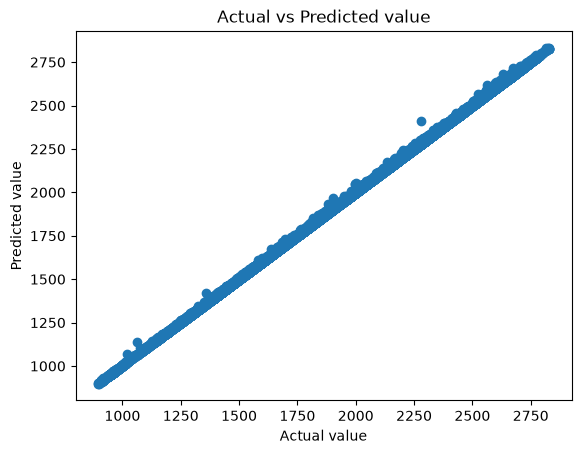

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Actual vs Predicted value")
plt.show()